In [3]:
import pandas as pd

file_path = "/content/drive/MyDrive/Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding='latin1')

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [4]:

# Step 5: Basic info
print("\nDataset Info:")
print(df.info())

# Step 6: Describe dataset
print("\nStatistical Summary:")
print(df.describe())

# Step 7: Check columns
print("\nColumn Names:")
print(df.columns)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float6

Dataset Loaded Successfully
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Cate

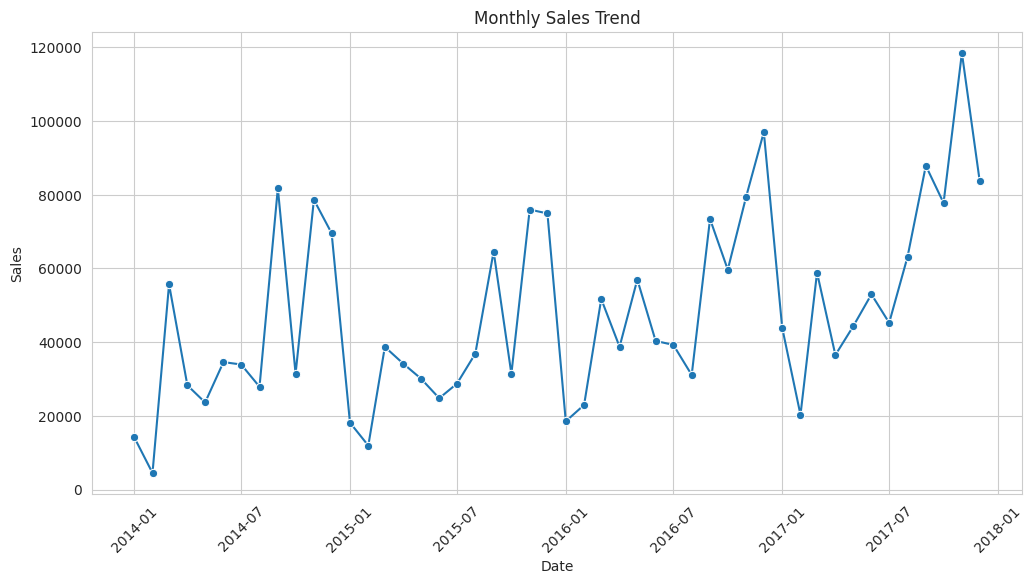

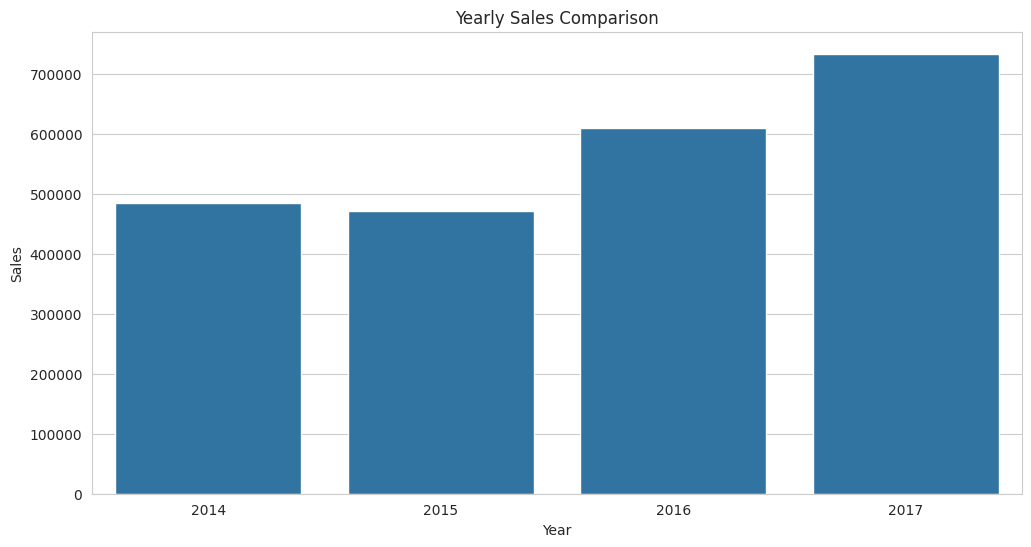

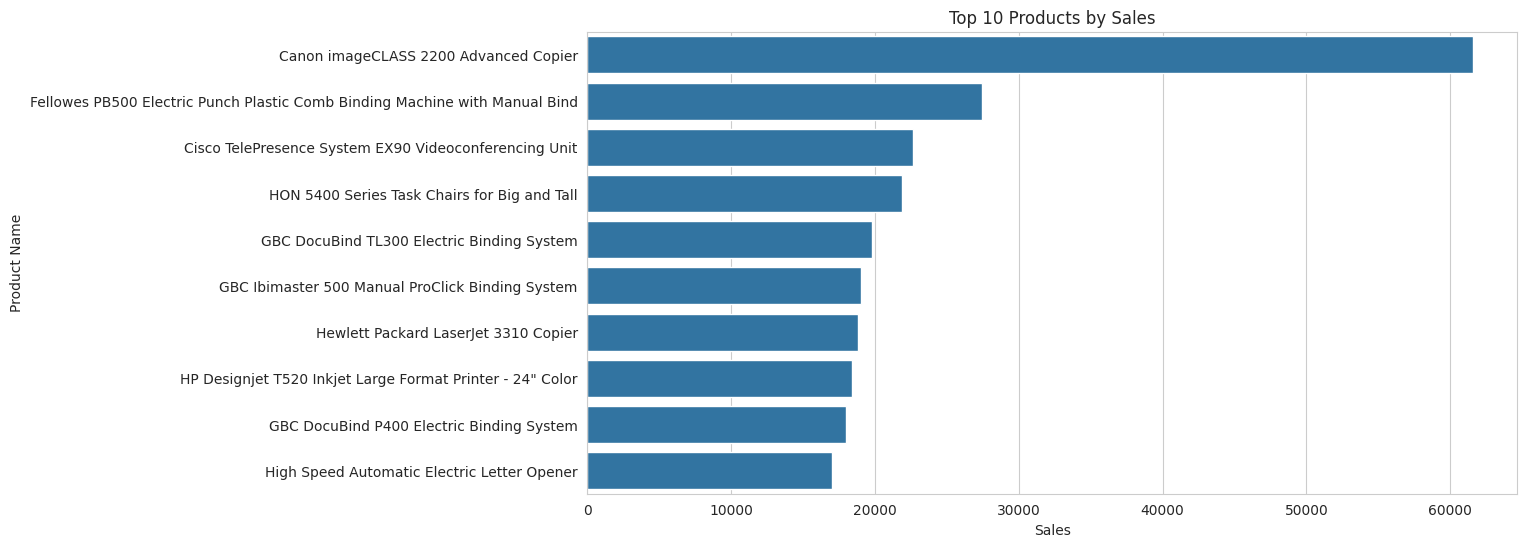

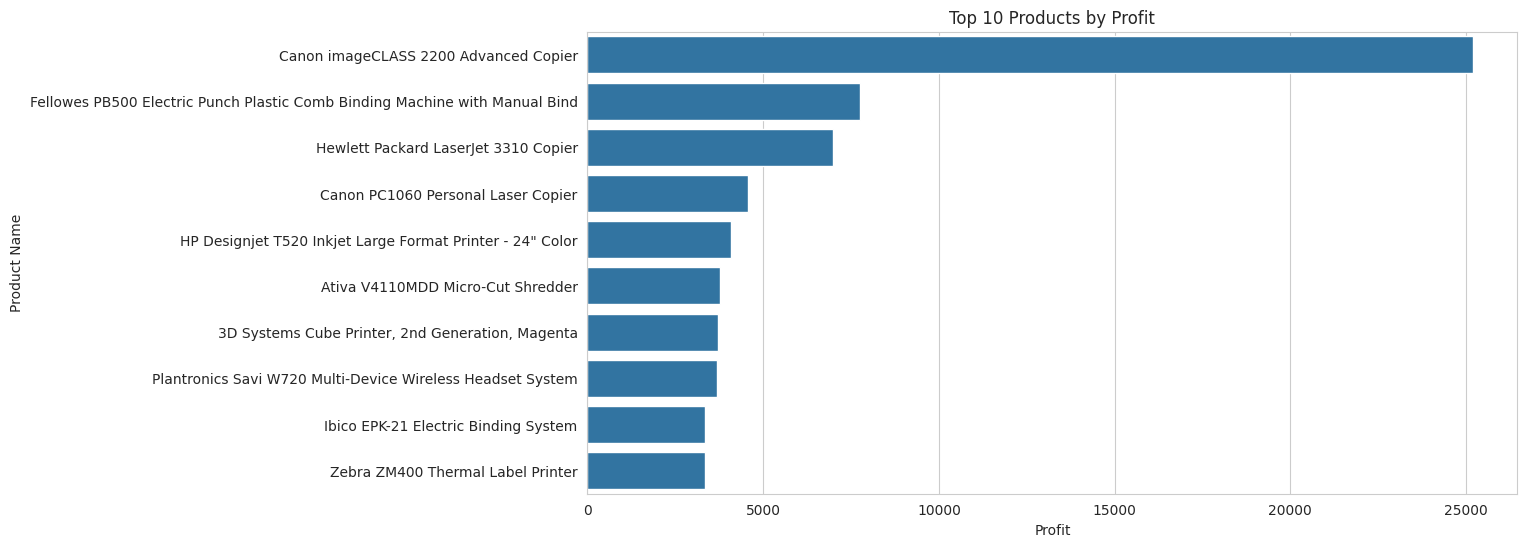

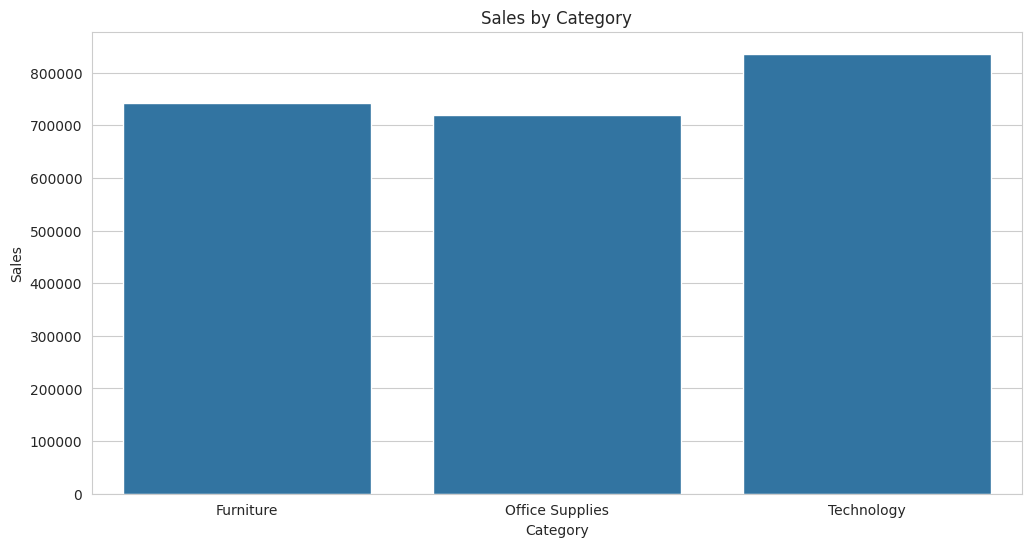

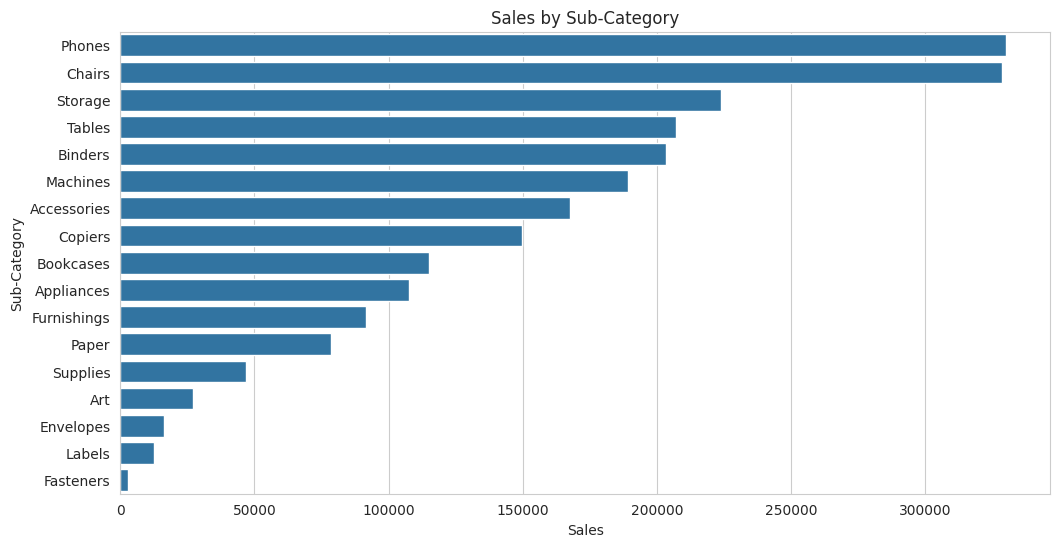

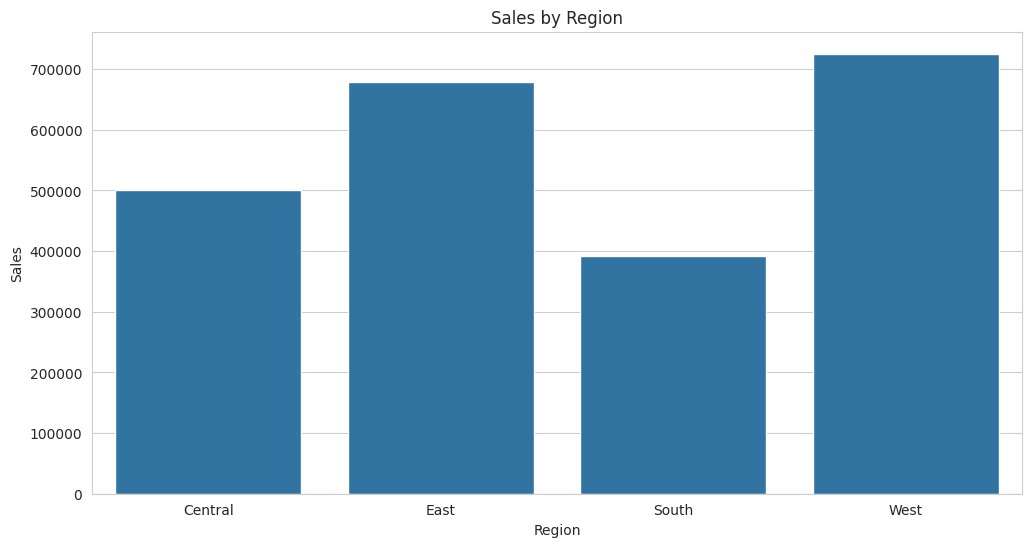

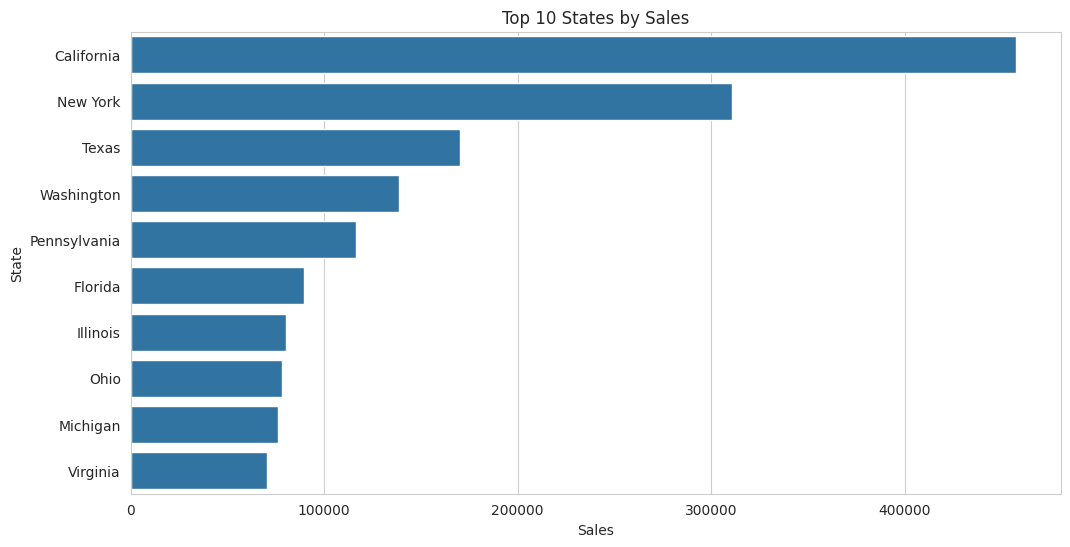

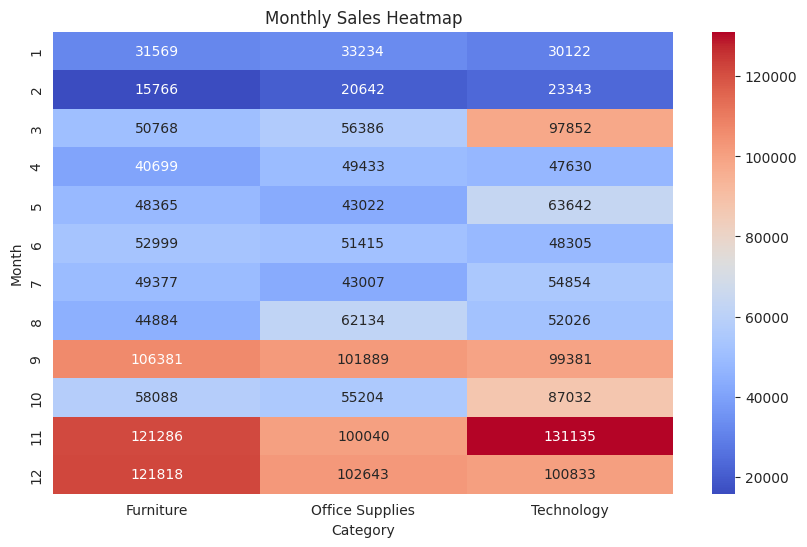

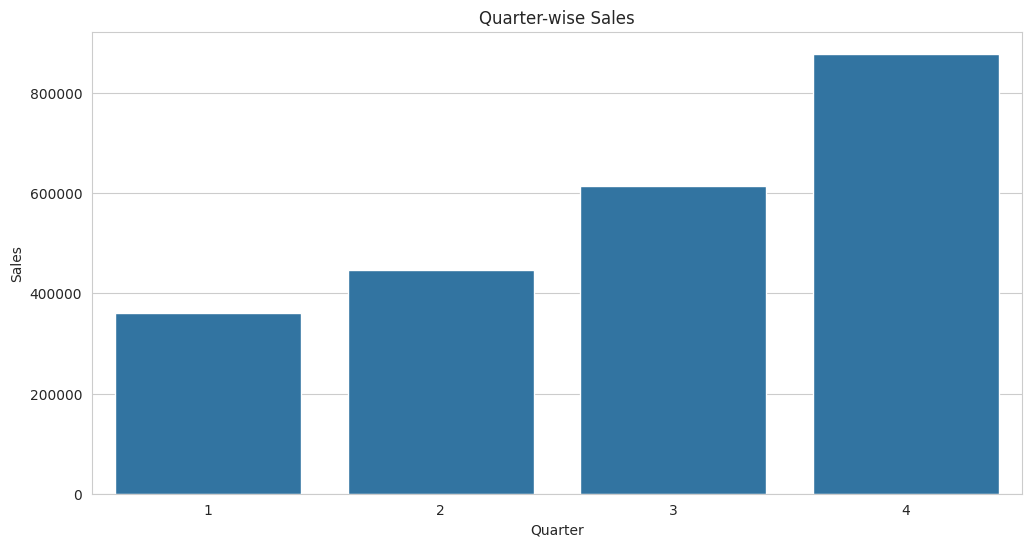

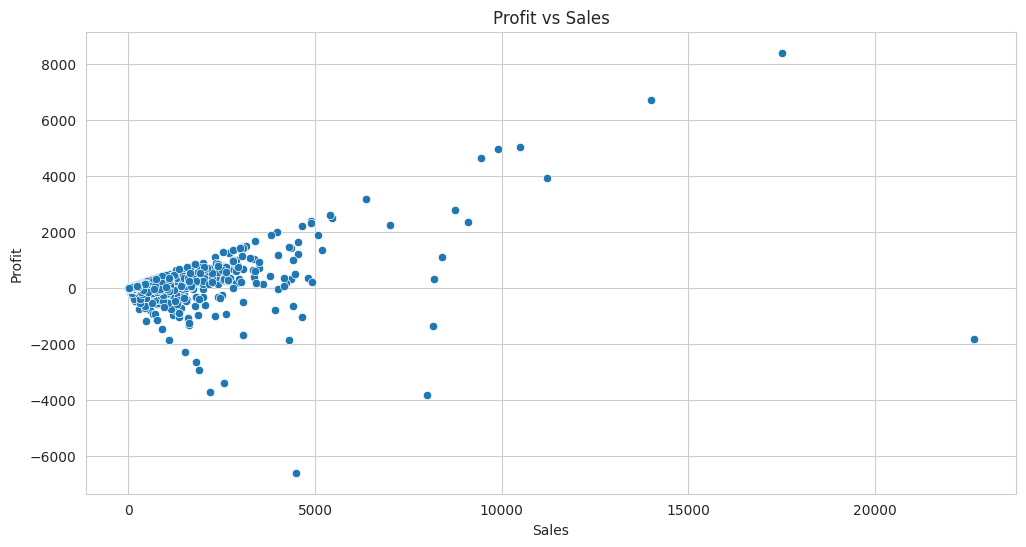

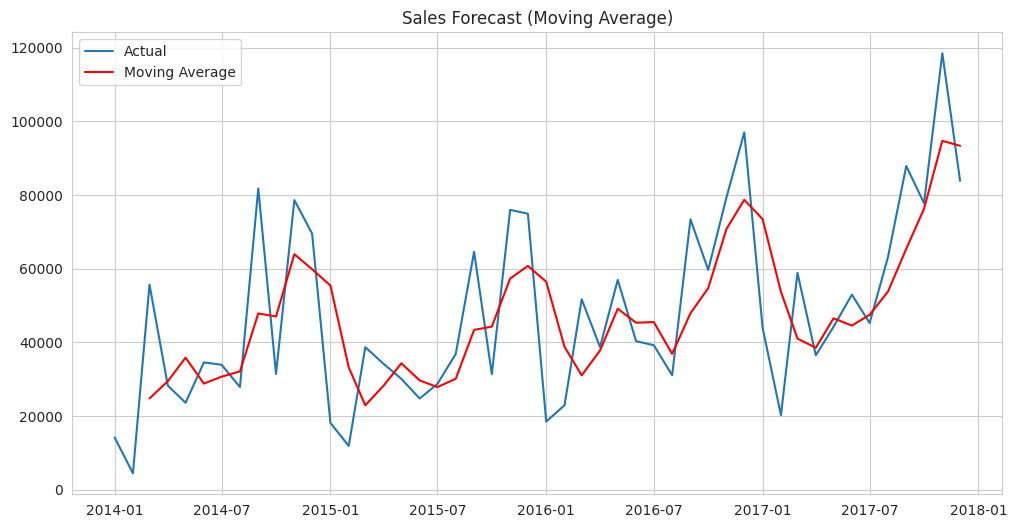

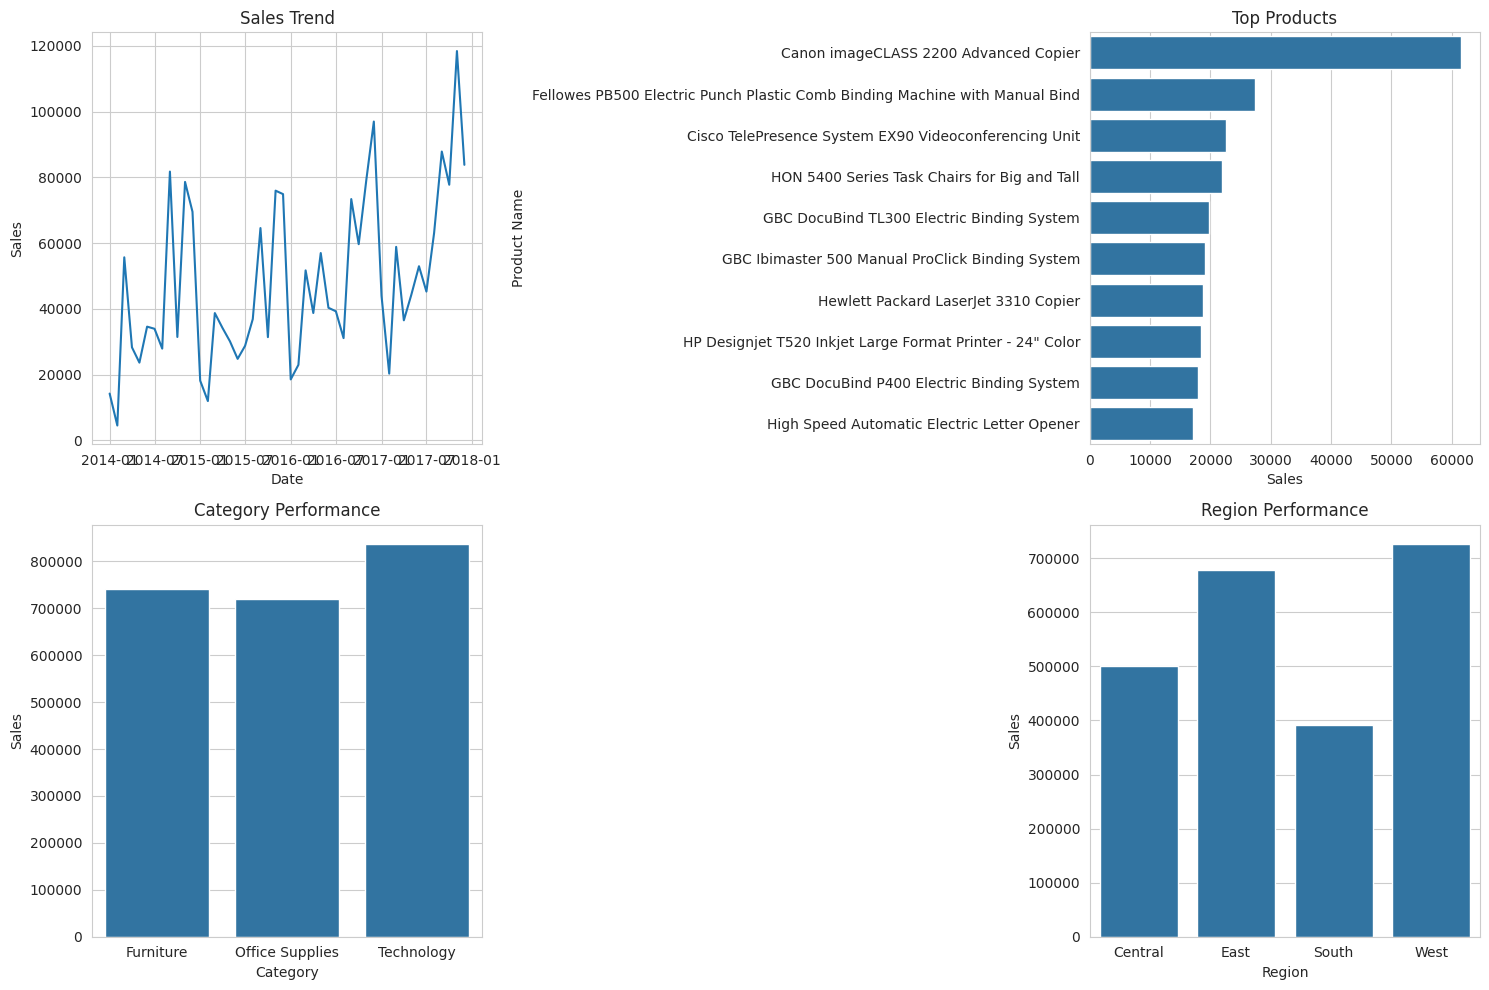


========= BUSINESS INSIGHTS =========
Best Selling Product: Canon imageCLASS 2200 Advanced Copier
Most Profitable Category: Technology
Peak Sales Month: 11
Top Region: West

All outputs saved in 'output' folder ✅


In [5]:
# ============================================
# E-COMMERCE SALES DATA ANALYTICS PROJECT
# ============================================





# Step 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# Create output folder
os.makedirs("output", exist_ok=True)

# Step 3: Load Dataset
file_path = "/content/drive/MyDrive/Sample - Superstore.csv"
df = pd.read_csv(file_path, encoding='latin1')

print("Dataset Loaded Successfully")
print(df.head())

# ============================================
# DATA PREPROCESSING
# ============================================

# Clean column names
df.columns = df.columns.str.strip()

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

# Handle missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

print("\nData Preprocessing Completed")

# ============================================
# SALES ANALYSIS
# ============================================

# Monthly Sales Trend
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(day=1))

plt.figure()
sns.lineplot(x='Date', y='Sales', data=monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.savefig("output/monthly_sales.png")
plt.show()

# Yearly Sales
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure()
sns.barplot(x='Year', y='Sales', data=yearly_sales)
plt.title("Yearly Sales Comparison")
plt.savefig("output/yearly_sales.png")
plt.show()

# ============================================
# PRODUCT ANALYSIS
# ============================================

top_products_sales = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure()
sns.barplot(x='Sales', y='Product Name', data=top_products_sales)
plt.title("Top 10 Products by Sales")
plt.savefig("output/top_products_sales.png")
plt.show()

top_products_profit = df.groupby('Product Name')['Profit'].sum().nlargest(10).reset_index()

plt.figure()
sns.barplot(x='Profit', y='Product Name', data=top_products_profit)
plt.title("Top 10 Products by Profit")
plt.savefig("output/top_products_profit.png")
plt.show()

# ============================================
# CATEGORY ANALYSIS
# ============================================

category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure()
sns.barplot(x='Category', y='Sales', data=category_sales)
plt.title("Sales by Category")
plt.savefig("output/category_sales.png")
plt.show()

sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure()
sns.barplot(x='Sales', y='Sub-Category', data=sub_category_sales)
plt.title("Sales by Sub-Category")
plt.savefig("output/subcategory_sales.png")
plt.show()

# ============================================
# REGIONAL ANALYSIS
# ============================================

region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure()
sns.barplot(x='Region', y='Sales', data=region_sales)
plt.title("Sales by Region")
plt.savefig("output/region_sales.png")
plt.show()

state_sales = df.groupby('State')['Sales'].sum().nlargest(10).reset_index()

plt.figure()
sns.barplot(x='Sales', y='State', data=state_sales)
plt.title("Top 10 States by Sales")
plt.savefig("output/state_sales.png")
plt.show()

# ============================================
# SEASONAL ANALYSIS
# ============================================

heatmap_data = df.pivot_table(values='Sales', index='Month', columns='Category', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Monthly Sales Heatmap")
plt.savefig("output/heatmap.png")
plt.show()

quarter_sales = df.groupby('Quarter')['Sales'].sum().reset_index()

plt.figure()
sns.barplot(x='Quarter', y='Sales', data=quarter_sales)
plt.title("Quarter-wise Sales")
plt.savefig("output/quarter_sales.png")
plt.show()

# ============================================
# SCATTER (Profit vs Sales)
# ============================================

plt.figure()
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Profit vs Sales")
plt.savefig("output/scatter.png")
plt.show()

# ============================================
# FORECASTING (Moving Average)
# ============================================

monthly_sales['MA'] = monthly_sales['Sales'].rolling(window=3).mean()

plt.figure()
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], label='Actual')
plt.plot(monthly_sales['Date'], monthly_sales['MA'], label='Moving Average', color='red')
plt.legend()
plt.title("Sales Forecast (Moving Average)")
plt.savefig("output/forecast.png")
plt.show()

# ============================================
# DASHBOARD
# ============================================

fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.lineplot(x='Date', y='Sales', data=monthly_sales, ax=axes[0,0])
axes[0,0].set_title("Sales Trend")

sns.barplot(x='Sales', y='Product Name', data=top_products_sales, ax=axes[0,1])
axes[0,1].set_title("Top Products")

sns.barplot(x='Category', y='Sales', data=category_sales, ax=axes[1,0])
axes[1,0].set_title("Category Performance")

sns.barplot(x='Region', y='Sales', data=region_sales, ax=axes[1,1])
axes[1,1].set_title("Region Performance")

plt.tight_layout()
plt.savefig("output/dashboard.png")
plt.show()

# ============================================
# BUSINESS INSIGHTS
# ============================================

print("\n========= BUSINESS INSIGHTS =========")

best_product = df.groupby('Product Name')['Sales'].sum().idxmax()
print("Best Selling Product:", best_product)

best_category = df.groupby('Category')['Profit'].sum().idxmax()
print("Most Profitable Category:", best_category)

peak_month = df.groupby('Month')['Sales'].sum().idxmax()
print("Peak Sales Month:", peak_month)

top_region = df.groupby('Region')['Sales'].sum().idxmax()
print("Top Region:", top_region)

print("\nAll outputs saved in 'output' folder ✅")